# Neutral Mutation Rates for Sites of Interest

## Introduction

In our V family DASM analysis, we discovered an intriguing pattern at specific sites located at the edges of CDRs (positions 38, 55, etc.). These sites exhibit a paradoxical combination of properties:

1. **Wide germline heterogeneity** - Multiple different amino acids are present across V gene families at these positions
2. **Entrenchment** - Despite this heterogeneity, there is a strong preference not to mutate between the different germline amino acids

This combination suggests these sites are under complex evolutionary constraints where the germline amino acid is highly optimized for each V gene context, but transitions between germline variants are strongly disfavored.

## Hypothesis and Approach

To understand the mechanistic basis of this entrenchment, we examine the **neutral mutation rates** at these sites using the Thrifty model. Our hypothesis is that entrenchment might correlate with intrinsic mutational properties of these positions.

We calculate neutral mutation rates using:
- The Thrifty neutral mutation model to predict position-specific rates
- A standardized branch length of 0.1 to ensure comparable rates across sites and amino acids
- We remove sites with more than one mutation in a codon in the pcp
- Both nucleotide-level and amino acid-level transition probabilities

## We find high neutral mutation rate for these sites

**Surprising Result**: Contrary to our initial expectations, Thrifty reveals that these entrenchment sites actually have **very high neutral mutation rates**. This unexpected finding suggests that the strong selective constraint we observe may be a direct consequence of high intrinsic mutability - positions that are highly mutable require stronger selective pressure to maintain their functional amino acids.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from Bio.Seq import Seq
import seaborn as sns

from torch.nn import functional as F

from netam import pretrained
from netam.models import DEFAULT_NEUTRAL_MODEL

from dnsmex.dxsm_data import pcp_df_of_nickname, anarci_dict
from dnsmex.local import localify
from netam.oe_plot import annotate_sites_df, annotate_site_csp_df, get_numbering_dict
from utils import add_germline_information

In [ ]:
dataset = "v1rodriguez"
#dataset = 'v1rodriguez_short'
neutral_model_name = DEFAULT_NEUTRAL_MODEL


class MutabilityContainer:
    def __init__(self, neutral_model_name, dataset):
        pcp_df = pcp_df_of_nickname(dataset, add_shm_outputs=True)
        self.pcp_df = pcp_df
        crepe = pretrained.load(neutral_model_name)
        
        self.rates, self.csp_logits = crepe(self.pcp_df["parent_heavy"])

        self.csp_rates = F.softmax(self.csp_logits, dim=2)


        anarci_path = anarci_dict[dataset]
        print(f"Using ANARCI path: {anarci_path}")
        if "imgt" in anarci_path:
            self.numbering_type = "IMGT"
        
        pcp_df_heavy = pcp_df

        for colname in pcp_df.columns:
            shortened_colname = colname[: -len("_heavy")]
            if colname.endswith("_heavy"):
                pcp_df_heavy[shortened_colname] = pcp_df_heavy[colname]

        self.pcp_df = pcp_df_heavy

        self.numbering, _ = get_numbering_dict(
            anarci_path['heavy'], self.pcp_df, verbose=True, checks="imgt"
        )

        self.create_nucleotide_neutral_rates_df()
        self.create_amino_acids_neutral_rates_df()
    
    def create_nucleotide_neutral_rates_df(self):
        """
        Create a dataframe with one row per sequence, site, and nucleotide.
        No aggregations - just raw rates and csp_logits.
        Includes codon information and transition details.
        
        Returns:
        - DataFrame with columns: sequence_idx, site, nucleotide, rate, csp_logit,
                                 current_codon, codon_position, current_nucleotide, 
                                 transition_from, transition_to
        """
        n_sequences = self.rates.shape[0]
        n_sites = self.rates.shape[1] 
        nucleotides = ['A', 'C', 'G', 'T']
        
        rows = []
        
        for seq_idx in range(n_sequences):
            parent_seq = self.pcp_df.iloc[seq_idx]['parent']
            seq_length = len(parent_seq)  # Get actual sequence length
            
            for site_idx in range(n_sites):
                rate = self.rates[seq_idx, site_idx].item()
                
                # Only process sites that exist in the sequence
                if site_idx < seq_length:
                    # Get codon information for this site
                    codon_start = (site_idx // 3) * 3
                    codon_position = site_idx % 3  # 0, 1, or 2 within the codon
                    
                    # Make sure we don't go beyond sequence length for codon
                    if codon_start + 2 < seq_length:
                        current_codon = parent_seq[codon_start:codon_start + 3]
                    else:
                        current_codon = None  # Incomplete codon at end
                    
                    current_nucleotide = parent_seq[site_idx]
                else:
                    # Sites beyond sequence length - model padding
                    current_codon = None
                    codon_position = None
                    current_nucleotide = None
                
                for nuc_idx, nucleotide in enumerate(nucleotides):
                    csp_rate = self.csp_rates[seq_idx, site_idx, nuc_idx].item()
                    
                    # Determine the transition being tested
                    if current_nucleotide is not None and current_codon is not None:
                        transition_from = current_nucleotide
                        transition_to = nucleotide
                        
                        # Calculate the resulting codon after transition
                        codon_list = list(current_codon)
                        codon_list[codon_position] = nucleotide
                        transition_codon = ''.join(codon_list)
                    else:
                        transition_from = None
                        transition_to = nucleotide
                        transition_codon = None
                    
                    rows.append({
                        'pcp_index': seq_idx,
                        'site': site_idx,
                        'nucleotide': nucleotide,
                        'rate': rate,
                        'csp': csp_rate,
                        'current_codon': current_codon,
                        'codon_position': codon_position,
                        'current_nucleotide': current_nucleotide,
                        'transition_codon': transition_codon
                    })
        
        nuc_neutral_df = pd.DataFrame(rows)
        nuc_neutral_df = nuc_neutral_df[~nuc_neutral_df.current_codon.isna()]


        # amino acid site annotation
        temp_annotation_df = nuc_neutral_df[['pcp_index', 'site']].drop_duplicates().copy()
        temp_annotation_df['unannotated_nuc_site'] = temp_annotation_df['site'].copy()
        temp_annotation_df['aa_site'] = temp_annotation_df.site // 3
        annotated_temp_annotation_df = annotate_sites_df(temp_annotation_df[['pcp_index', 'aa_site']].drop_duplicates(), self.pcp_df, numbering_dict=self.numbering, add_codons_aas=True)
        temp_annotation_df = pd.merge(annotated_temp_annotation_df, temp_annotation_df[['pcp_index', 'aa_site', 'unannotated_nuc_site']], on=['pcp_index', 'aa_site'], how='inner')
        temp_annotation_df.drop(columns=['aa_site'], inplace=True)
        temp_annotation_df = temp_annotation_df[['pcp_index', 'site', 'unannotated_nuc_site', 'is_cdr', 'parent_codon', 'parent_aa','child_codon', 'child_aa',]].rename(columns={'unannotated_nuc_site':'nuc_site'})
        nuc_neutral_df = pd.merge(nuc_neutral_df.rename(columns={'site':'nuc_site'}), temp_annotation_df, on=['pcp_index', 'nuc_site'], how='inner')

        # change rate to praobiblity for constant branch length
        branch_length = 0.1
        nuc_neutral_df['probability'] = nuc_neutral_df['rate'].apply(lambda x: 1.0 - np.exp(-branch_length * x))

        # get complete rate of mutation to specific nucleotide
        nuc_neutral_df['csp_complete_probability'] = nuc_neutral_df['probability'] * nuc_neutral_df['csp']

        # add amino acids transition information
        nuc_neutral_df['current_aa']  = nuc_neutral_df.apply(lambda row: Seq(row['current_codon']).translate() if row['transition_codon'] is not None else None, axis=1)
        nuc_neutral_df['transition_aa'] = nuc_neutral_df.apply(lambda row: Seq(row['transition_codon']).translate() if row['transition_codon'] is not None else None, axis=1)

        # reorder and rename columns
        nuc_neutral_df = nuc_neutral_df[['pcp_index', 'nuc_site', 'current_nucleotide', 'nucleotide', 'rate', 'csp', 'probability', 'csp_complete_probability', 
                                    'codon_position', 'current_codon', 'transition_codon', 'current_aa','transition_aa', 'site', 'is_cdr', 'parent_codon', 
                                    'parent_aa', 'child_codon', 'child_aa',]].rename(columns={'nucleotide':'transition_nucleotide'})

        nuc_neutral_df = add_germline_information(self.pcp_df, nuc_neutral_df, germline_codons_path="germline/germline_codons.csv")

        self.nuc_neutral_df = nuc_neutral_df

    def create_amino_acids_neutral_rates_df(self):
        aa_neutral_df = self.nuc_neutral_df.groupby([
        'pcp_index', 'site', 'current_aa', 'transition_aa', 'parent_codon', 'parent_aa', 
        'child_codon', 'child_aa', 'is_cdr'], sort=False).agg({'csp_complete_probability': 'sum'}).reset_index()

        aa_neutral_df = aa_neutral_df[aa_neutral_df.current_aa != aa_neutral_df.transition_aa]

        aa_neutral_df = add_germline_information(self.pcp_df, aa_neutral_df, germline_codons_path="germline/germline_codons.csv")
        self.aa_neutral_df = aa_neutral_df




MutabilityContainer = MutabilityContainer(neutral_model_name, dataset)


Loading /home/nharel/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', '440')]
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip


/home/nharel/re/dnsm-experiments-1/dnsmex/dxsm_data.py:476: UserWarning: Using ThriftyHumV0.2-59. Make sure this is an appropriate choice for your model, or use `netam.framework.add_shm_model_outputs_to_pcp_df` directly to provide the correct neutral model.
  warn(
Evaluating model: 100%|██████████| 2176/2176 [00:04<00:00, 438.48it/s]


Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip


Evaluating model: 100%|██████████| 21752/21752 [00:29<00:00, 741.26it/s]


Using ANARCI path: {'heavy': '/home/nharel/data/v3/anarci/rodriguez-airr-seq-race-prod-NoWinCheck_igh_imgt.csv'}
ANARCI seq length mismatch! sample-igg-SC-13 2013
ANARCI seq length mismatch! sample-igg-SC-15 925
Invalid IMGT insertion: 68.1 sample-igg-SC-18 440
ANARCI seq length mismatch! sample-igg-SC-19 1803
IMGT mismatch with CDR annotation! sample-igg-W-25 4
IMGT mismatch with CDR annotation! sample-igg-W-19 41
Invalid IMGT insertion: 119.1 sample-igg-W-37 140
IMGT mismatch with CDR annotation! sample-igg-W-37 1
Invalid IMGT insertion: 119.1 sample-igg-W-3 17
Invalid IMGT insertion: 119.1 sample-igg-W-34 200


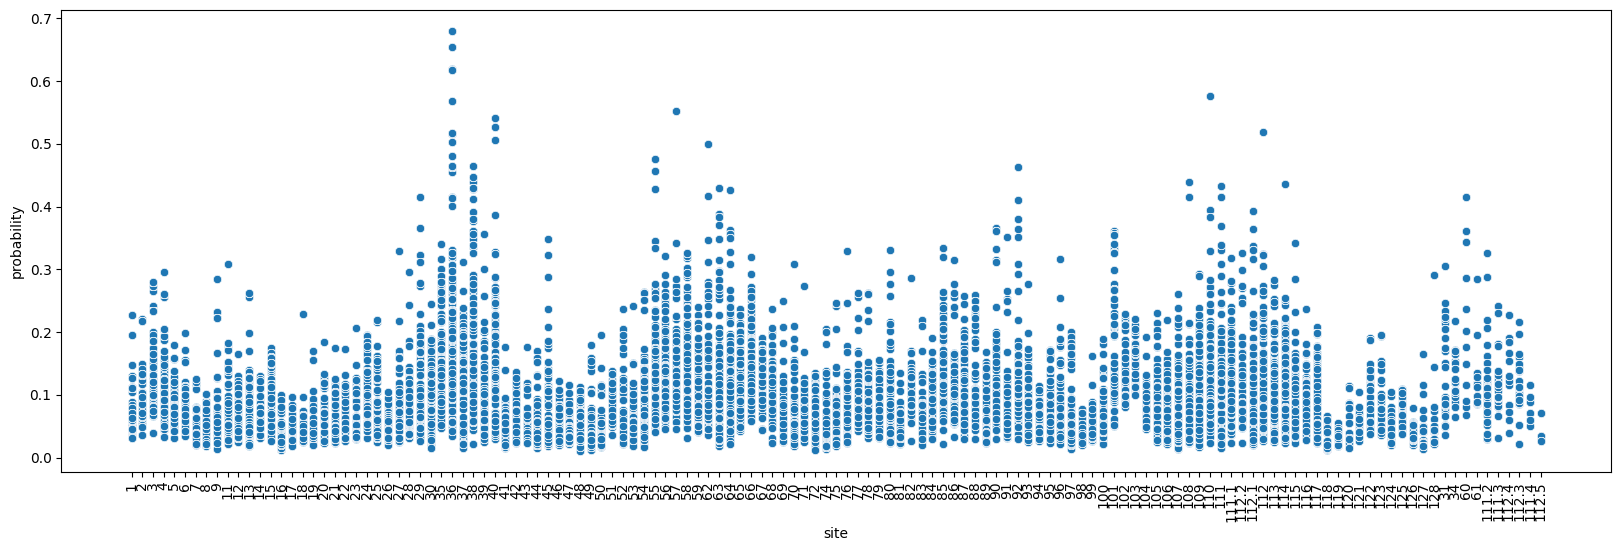

In [3]:
fix, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(data=MutabilityContainer.nuc_neutral_df, x='site', y='probability',ax=ax)
ax.tick_params(axis='x', rotation=90)


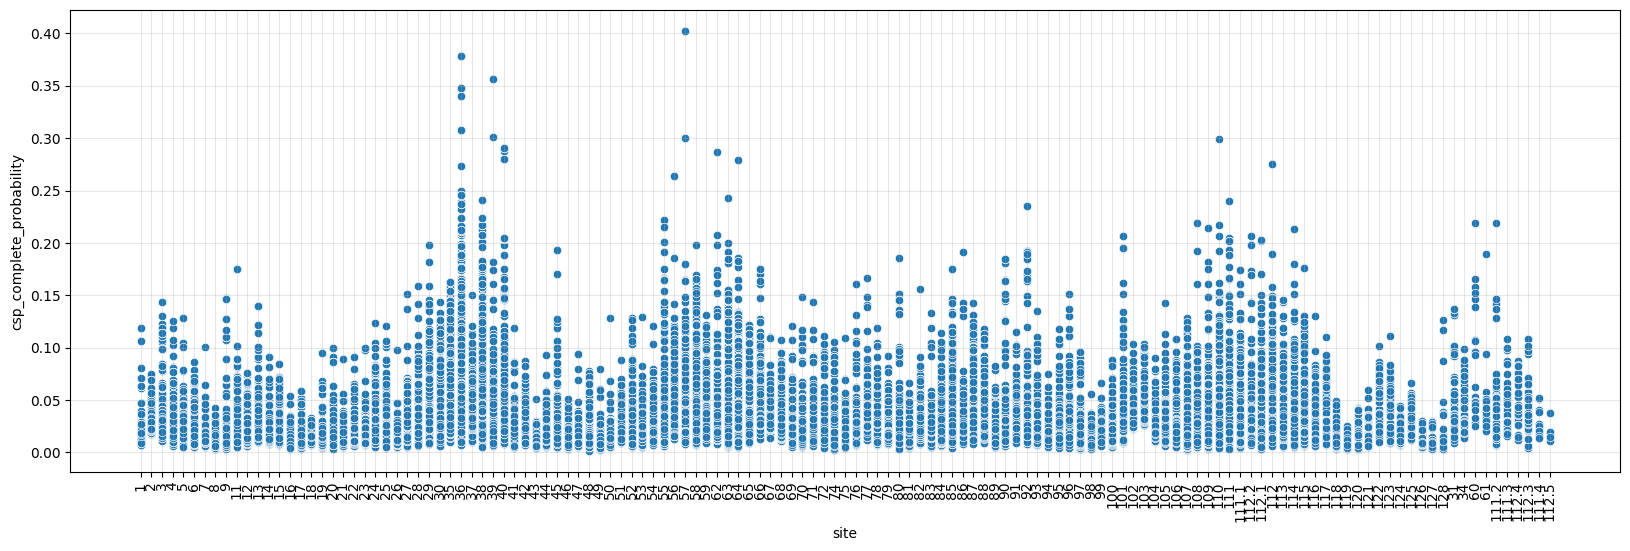

In [83]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(MutabilityContainer.aa_neutral_df, x='site', y='csp_complete_probability', ax=ax)

# Rotate labels
ax.tick_params(axis='x', rotation=90)
ax.grid(True, alpha=0.3)

# Add minor grid lines for every site
ax.set_xticks(range(0, 119), minor=True)
ax.grid(True, which='minor', alpha=0.1)

In [12]:
MutabilityContainer.nuc_neutral_df

,pcp_index,nuc_site,current_nucleotide,transition_nucleotide,rate,csp,probability,csp_complete_probability,codon_position,current_codon,transition_codon,current_aa,transition_aa,site,is_cdr,parent_codon,parent_aa,child_codon,child_aa
0,0,0,C,A,0.311750,0.233768,0.030694,0.007175,0.0,CAG,AAG,(Q),(K),1,False,CAG,Q,CAG,Q
1,0,0,C,C,0.311750,0.000000,0.030694,0.000000,0.0,CAG,CAG,(Q),(Q),1,False,CAG,Q,CAG,Q
2,0,0,C,G,0.311750,0.303099,0.030694,0.009303,0.0,CAG,GAG,(Q),(E),1,False,CAG,Q,CAG,Q
3,0,0,C,T,0.311750,0.463133,0.030694,0.014215,0.0,CAG,TAG,(Q),(*),1,False,CAG,Q,CAG,Q
4,0,1,A,A,0.456275,0.000000,0.044602,0.000000,1.0,CAG,CAG,(Q),(Q),1,False,CAG,Q,CAG,Q
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144439,98,361,C,T,0.252441,0.431497,0.024928,0.010756,1.0,TCA,TTA,(S),(L),128,False,TCA,S,TCA,S
144440,98,362,A,A,0.447001,0.000000,0.043716,0.000000,2.0,TCA,TCA,(S),(S),128,False,TCA,S,TCA,S
144441,98,362,A,C,0.447001,0.400870,0.043716,0.017524,2.0,TCA,TCC,(S),(S),128,False,TCA,S,TCA,S
144442,98,362,A,G,0.447001,0.267013,0.043716,0.011673,2.0,TCA,TCG,(S),(S),128,False,TCA,S,TCA,S


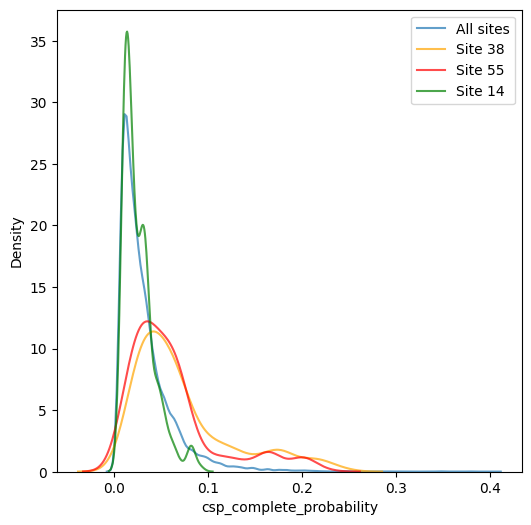

In [66]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.kdeplot(result.csp_complete_probability, alpha=0.7, label='All sites', ax=ax)
sns.kdeplot(result[result.site == '38'].csp_complete_probability, alpha=0.7, color='orange', label='Site 38', ax=ax)
sns.kdeplot(result[result.site == '55'].csp_complete_probability, alpha=0.7, color='red', label='Site 55', ax=ax)
sns.kdeplot(result[result.site == '14'].csp_complete_probability, alpha=0.7, color='green', label='Site 14', ax=ax)


ax.legend()
plt.show()

/tmp/ipykernel_4050696/3753984728.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['site'] = plot_data['site'].astype(float)


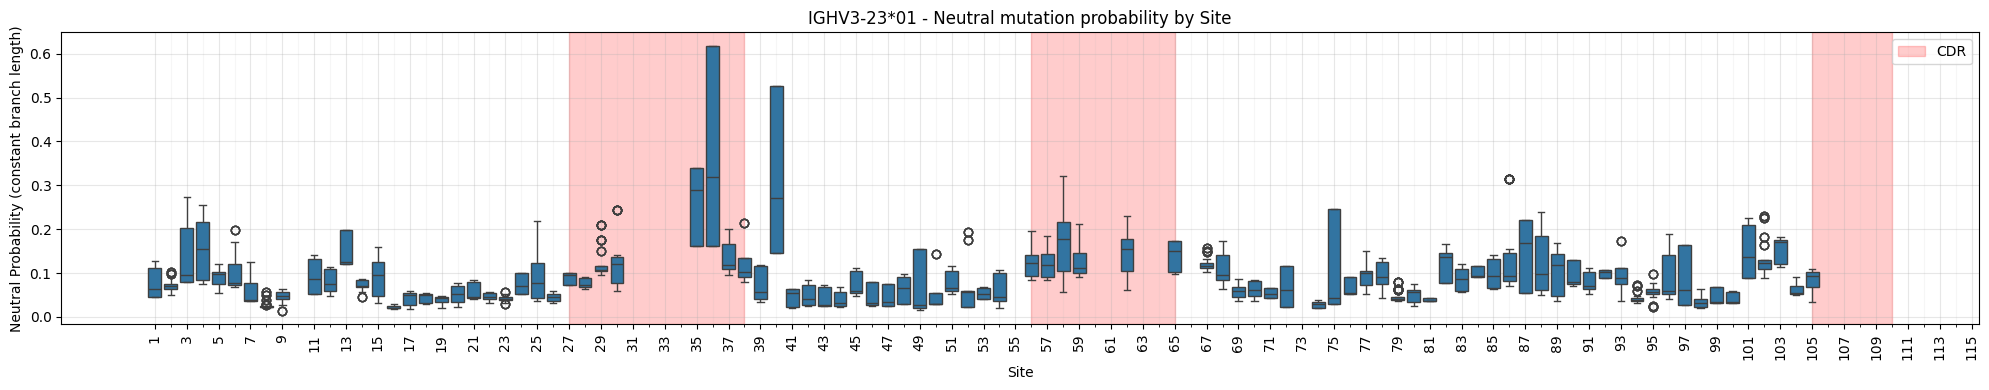

In [16]:
v3_pcps = MutabilityContainer.pcp_df[MutabilityContainer.pcp_df['v_gene_heavy'].str.startswith('IGHV3-23*01')].index.tolist()

plot_data = MutabilityContainer.nuc_neutral_df[(MutabilityContainer.nuc_neutral_df.pcp_index.isin(v3_pcps)) & (MutabilityContainer.nuc_neutral_df.is_germline_aa == True)]
#plot_data = MutabilityContainer.nuc_neutral_df[(MutabilityContainer.nuc_neutral_df.pcp_index.isin(v3_pcps))]

plot_data['site'] = plot_data['site'].astype(float)

# Create a complete range of sites from 1 to 119
all_sites = pd.DataFrame({'site': range(1, 120)})

# Get all unique pcp_index values to create dummy rows for missing sites
unique_pcps = plot_data['pcp_index'].unique()

# Create a complete grid of all pcp_index x site combinations
complete_grid = []
for pcp in unique_pcps:
    for site in range(1, 120):
        complete_grid.append({'pcp_index': pcp, 'site': site})

complete_df = pd.DataFrame(complete_grid)

# Merge with actual data, filling missing values with NaN
plot_data_complete = pd.merge(complete_df, plot_data, on=['pcp_index', 'site'], how='left')

fig, ax = plt.subplots(figsize=(20, 4))

# Create the boxplot with complete data (NaN values will be ignored automatically)
sns.boxplot(data=plot_data_complete, x='site', y='probability', ax=ax)

# Set x-axis ticks to show every 2nd site
ax.set_xticks(range(0, 119, 2))
ax.set_xticklabels(range(1, 120, 2))

# Rotate labels
ax.tick_params(axis='x', rotation=90)
ax.grid(True, alpha=0.3)

# Add minor grid lines for every site
ax.set_xticks(range(0, 119), minor=True)
ax.grid(True, which='minor', alpha=0.1)

# Add labels
ax.set_xlabel('Site')
ax.set_ylabel('Neutral Probability (constant branch length)')
ax.set_title('IGHV3-23*01 - Neutral mutation probability by Site')

# Define CDR regions
cdr_regions = [
    (27, 38),   # CDR1
    (56, 65),   # CDR2
    (105, 110)  # CDR3 (shortened for V genes only)
]

# Add CDR background regions - now the indexing matches site numbers directly
for cdr_start, cdr_end in cdr_regions:
    # Convert from 1-based site numbering to 0-based boxplot indexing
    start_idx = cdr_start - 1
    end_idx = cdr_end - 1 
    ax.axvspan(start_idx, end_idx, alpha=0.2, color='red', label='CDR' if cdr_start == cdr_regions[0][0] else "")

# Add legend
ax.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_4013145/2026493071.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['site'] = plot_data['site'].astype(float)
/tmp/ipykernel_4013145/2026493071.py:21: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  plot_data_complete = pd.merge(complete_df, plot_data, on=['pcp_index', 'site'], how='left')


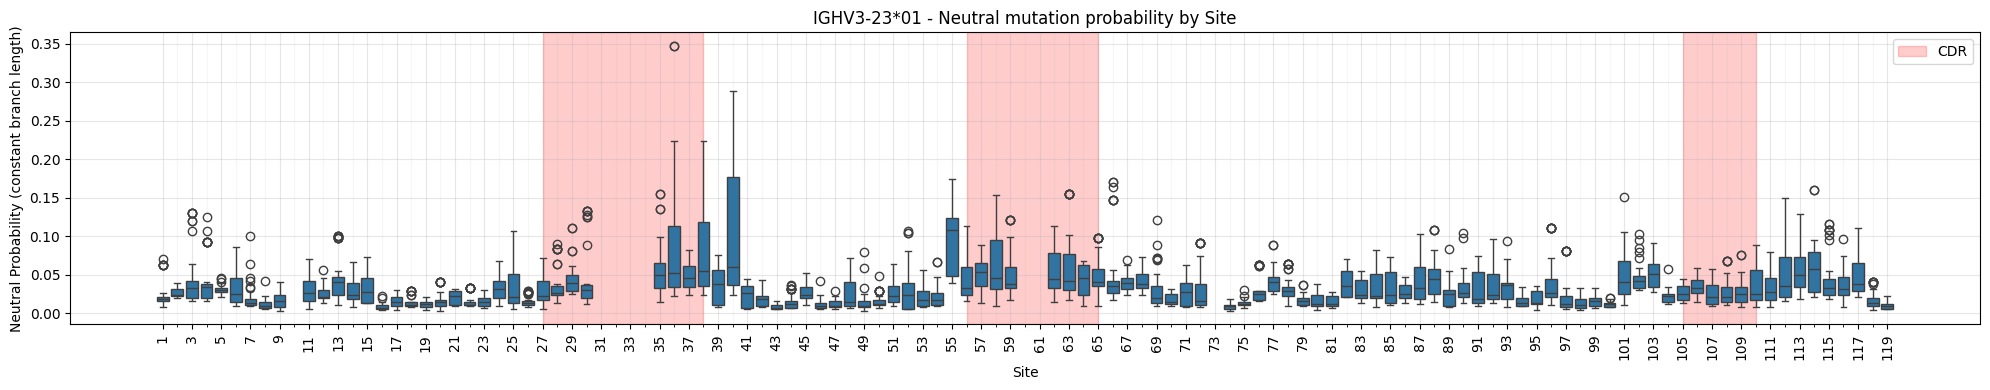

In [86]:
v3_pcps = MutabilityContainer.pcp_df[MutabilityContainer.pcp_df['v_gene_heavy'].str.startswith('IGHV3-23*01')].index.tolist()

plot_data = MutabilityContainer.aa_neutral_df[(MutabilityContainer.aa_neutral_df.pcp_index.isin(v3_pcps))]
plot_data['site'] = plot_data['site'].astype(float)

# Create a complete range of sites from 1 to 119
all_sites = pd.DataFrame({'site': range(1, 120)})

# Get all unique pcp_index values to create dummy rows for missing sites
unique_pcps = plot_data['pcp_index'].unique()

# Create a complete grid of all pcp_index x site combinations
complete_grid = []
for pcp in unique_pcps:
    for site in range(1, 120):
        complete_grid.append({'pcp_index': pcp, 'site': site})

complete_df = pd.DataFrame(complete_grid)

# Merge with actual data, filling missing values with NaN
plot_data_complete = pd.merge(complete_df, plot_data, on=['pcp_index', 'site'], how='left')

fig, ax = plt.subplots(figsize=(20, 4))

# Create the boxplot with complete data (NaN values will be ignored automatically)
sns.boxplot(data=plot_data_complete, x='site', y='csp_complete_probability', ax=ax)

# Set x-axis ticks to show every 2nd site
ax.set_xticks(range(0, 119, 2))
ax.set_xticklabels(range(1, 120, 2))

# Rotate labels
ax.tick_params(axis='x', rotation=90)
ax.grid(True, alpha=0.3)

# Add minor grid lines for every site
ax.set_xticks(range(0, 119), minor=True)
ax.grid(True, which='minor', alpha=0.1)

# Add labels
ax.set_xlabel('Site')
ax.set_ylabel('Neutral Probability (constant branch length)')
ax.set_title('IGHV3-23*01 - Neutral mutation probability by Site')

# Define CDR regions
cdr_regions = [
    (27, 38),   # CDR1
    (56, 65),   # CDR2
    (105, 110)  # CDR3 (shortened for V genes only)
]

# Add CDR background regions - now the indexing matches site numbers directly
for cdr_start, cdr_end in cdr_regions:
    # Convert from 1-based site numbering to 0-based boxplot indexing
    start_idx = cdr_start - 1
    end_idx = cdr_end - 1 
    ax.axvspan(start_idx, end_idx, alpha=0.2, color='red', label='CDR' if cdr_start == cdr_regions[0][0] else "")

# Add legend
ax.legend()

plt.tight_layout()
plt.show()

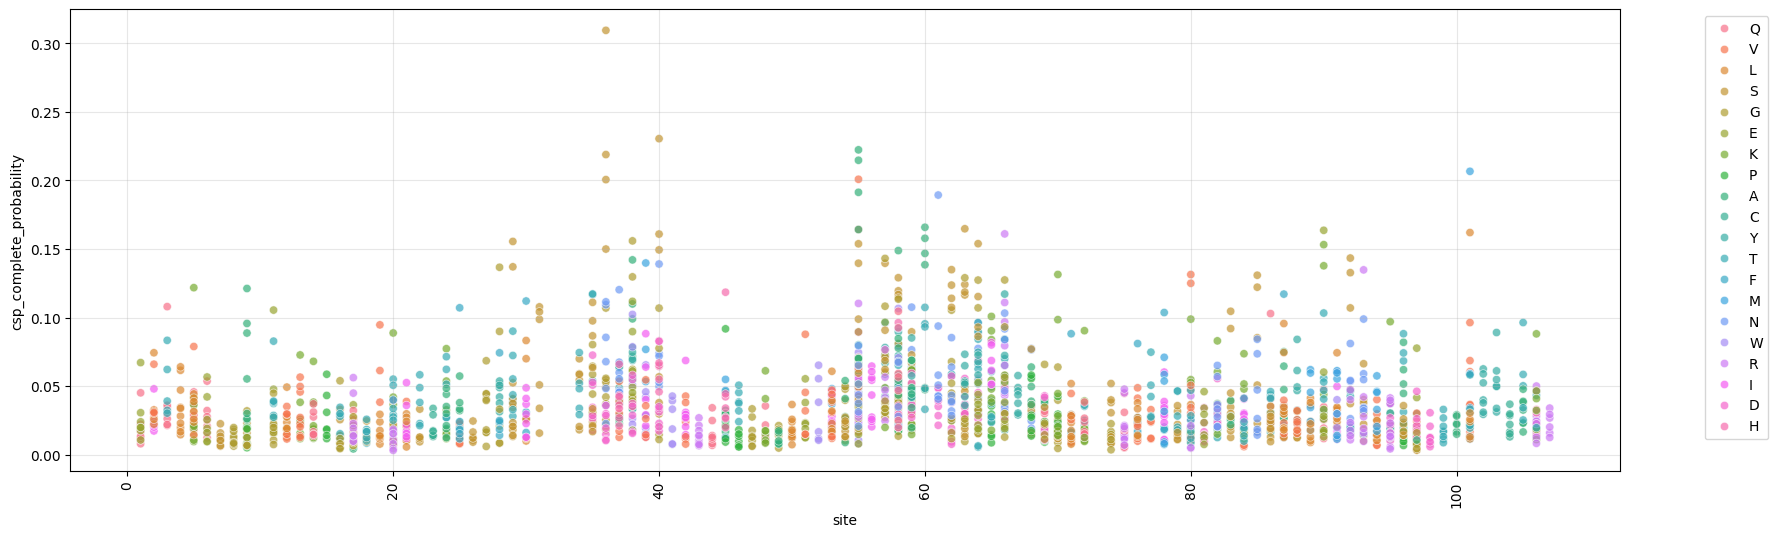

In [9]:
fig, ax = plt.subplots(figsize=(20, 6))
plot_data = MutabilityContainer.aa_neutral_df[MutabilityContainer.aa_neutral_df.is_germline_aa == True].groupby(['site', 'current_aa', 'transition_aa'], sort=False).agg({'csp_complete_probability':'mean'}).reset_index()
sns.scatterplot(data=plot_data,
                x='site', y='csp_complete_probability', hue='current_aa', alpha=0.7)
# Rotate labels
ax.tick_params(axis='x', rotation=90)
ax.grid(True, alpha=0.3)

# move lgened to outside
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [97]:
plot_data[plot_data.site == '38']

,site,current_aa,transition_aa,csp_complete_probability
193,38,(A),(T),0.106053
194,38,(A),(P),0.067095
195,38,(A),(S),0.050631
196,38,(A),(D),0.077313
197,38,(A),(G),0.148288
198,38,(A),(V),0.097921
881,38,(Y),(N),0.033223
882,38,(Y),(H),0.068781
883,38,(Y),(D),0.033440
884,38,(Y),(S),0.054440


In [98]:
MutabilityContainer.pcp_df

,orig_pcp_idx,sample_id,family,parent_name,parent_heavy,child_name,child_heavy,branch_length,depth,distance,...,cdr1_codon_start,cdr1_codon_end,cdr2_codon_start,cdr2_codon_end,cdr3_codon_start,cdr3_codon_end,j_gene,v_family,nt_rates,nt_csps
0,16,sample-igg-SC-24,1401,Node1,CAGGTGCAGCTGGTGCAATCTGGGTCTGAGTTGAAGAAGCCTGGGG...,1TGCGTTGTAGCT,CAGATCCAACTGGTCCAATCTGGGTCTGACTTGAAAAAGCCTGGGG...,0.082506,2,0.096444,...,75,96,150,171,288,333,IGHJ4*02,IGHV7,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
1,17,sample-igg-SC-24,1401,Node1,CAGGTGCAGCTGGTGCAATCTGGGTCTGAGTTGAAGAAGCCTGGGG...,Node2,CAGGTGCAGTTGGTGCAATCTGGGTCTGAGTTGAAGAAGCCTGGGG...,0.018034,2,0.031971,...,75,96,150,171,288,333,IGHJ4*02,IGHV7,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
2,32,sample-igg-SC-24,474,Node1,CAGCTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAGGCCTTCGG...,Node2,CAGCTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAGGCCTTCGG...,0.002823,2,0.079722,...,75,96,150,168,285,318,IGHJ4*02,IGHV4,"[tensor(0.5329), tensor(0.6757), tensor(2.1780...","[[tensor(0.2261), tensor(0.), tensor(0.2757), ..."
3,45,sample-igg-SC-24,238,Node1,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,1GGGCACTATGCA,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,0.029887,2,0.094379,...,75,102,156,174,291,321,IGHJ6*02,IGHV4,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
4,46,sample-igg-SC-24,238,Node1,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,1GCAGGGCACTCT,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,0.005211,2,0.069703,...,75,102,156,174,291,321,IGHJ6*02,IGHV4,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,506,sample-igg-SC-24,741,Node3,CAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,1TTCTTCTGGGAC,CAGGTGCAGTTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,0.096086,3,0.123178,...,75,96,150,171,288,327,IGHJ4*02,IGHV3,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
95,507,sample-igg-SC-24,741,Node3,CAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,1TGTATAAGTTGG,CAGGTGCACCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGAA...,0.107150,3,0.134241,...,75,96,150,171,288,327,IGHJ4*02,IGHV3,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
96,531,sample-igg-SC-24,72,Node1,CAGGTGCAACTGGTGGAATCTGGGGGAGACTTGGTCAAGCCTGGAG...,1TGTGGATTTAAC,CAGGTGCAACTGGTGGAATCTGGGGGAGACTTGGTCAAGCCTGGAG...,0.002876,2,0.097942,...,75,96,150,171,288,312,IGHJ1*01,IGHV3,"[tensor(0.3117), tensor(0.4563), tensor(0.8237...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
97,541,sample-igg-SC-24,383,Node1,CAGGTGCAGCTGCAGGAGTCGGACCCAGGACTGGTGAAGCCTTCGG...,1TCTTTGCTAGTG,CAGGTGCAGCTGCAGGAGTCGGACCCAGGACTGGTGAAGCCTTCGG...,0.005669,2,0.163680,...,75,99,153,171,288,321,IGHJ4*02,IGHV4,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."


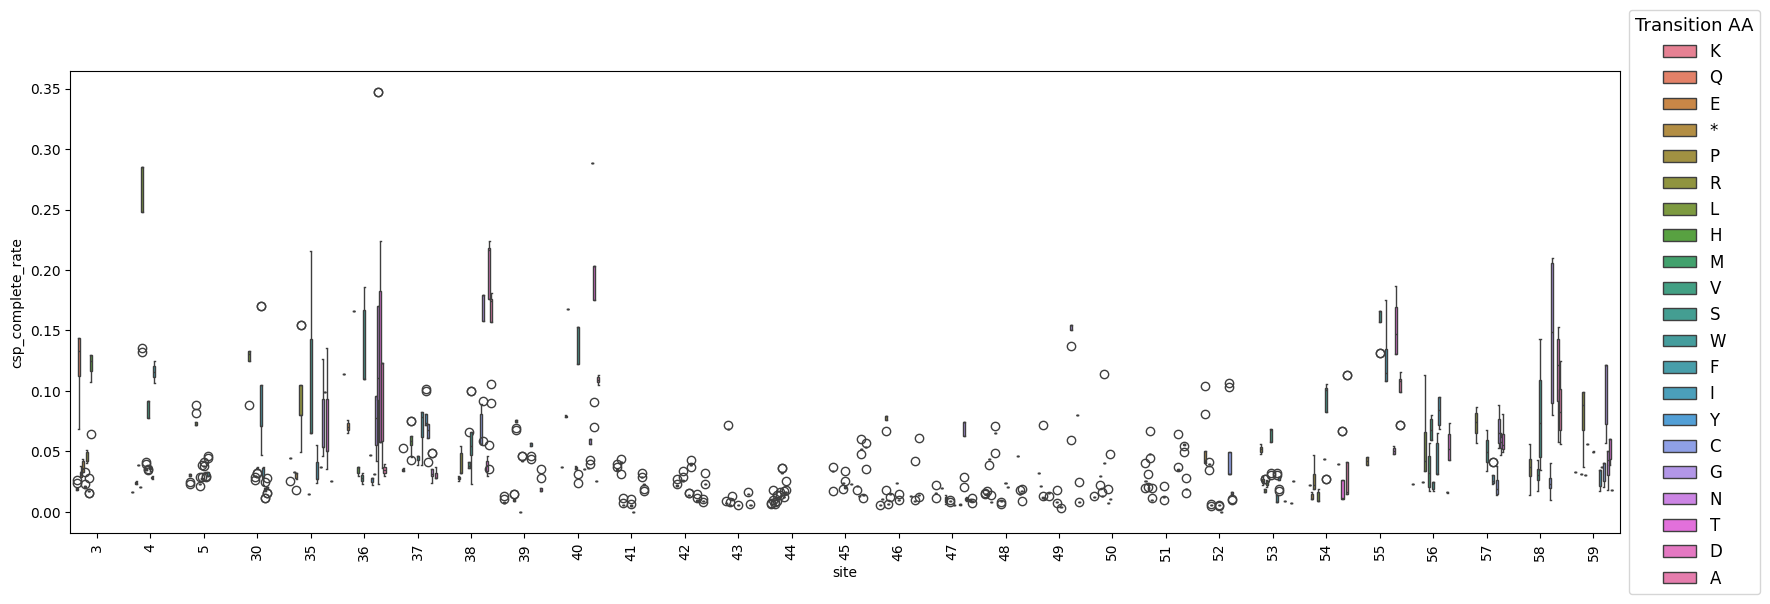

In [49]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(data=plot_data[(plot_data.site.str.startswith('3')) | (plot_data.site.str.startswith('4')) + (plot_data.site.str.startswith('5'))], x='site', y='csp_complete_rate', hue='transition_aa', ax=ax)
ax.tick_params(axis='x', rotation=90)
# move legend to the right
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Transition AA', fontsize=12, title_fontsize='13')


In [ ]:
## add germline

df = 

<Axes: xlabel='site', ylabel='count'>

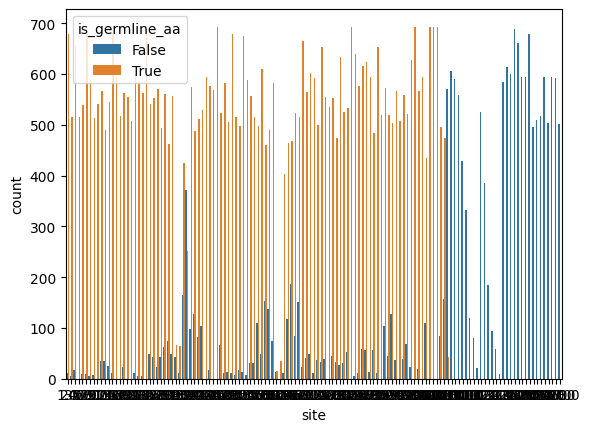

In [6]:
sns.countplot(df, x='site', hue='is_germline_aa')

In [102]:
MutabilityContainer.pcp_df

,orig_pcp_idx,sample_id,family,parent_name,parent_heavy,child_name,child_heavy,branch_length,depth,distance,...,cdr1_codon_start,cdr1_codon_end,cdr2_codon_start,cdr2_codon_end,cdr3_codon_start,cdr3_codon_end,j_gene,v_family,nt_rates,nt_csps
0,16,sample-igg-SC-24,1401,Node1,CAGGTGCAGCTGGTGCAATCTGGGTCTGAGTTGAAGAAGCCTGGGG...,1TGCGTTGTAGCT,CAGATCCAACTGGTCCAATCTGGGTCTGACTTGAAAAAGCCTGGGG...,0.082506,2,0.096444,...,75,96,150,171,288,333,IGHJ4*02,IGHV7,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
1,17,sample-igg-SC-24,1401,Node1,CAGGTGCAGCTGGTGCAATCTGGGTCTGAGTTGAAGAAGCCTGGGG...,Node2,CAGGTGCAGTTGGTGCAATCTGGGTCTGAGTTGAAGAAGCCTGGGG...,0.018034,2,0.031971,...,75,96,150,171,288,333,IGHJ4*02,IGHV7,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
2,32,sample-igg-SC-24,474,Node1,CAGCTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAGGCCTTCGG...,Node2,CAGCTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAGGCCTTCGG...,0.002823,2,0.079722,...,75,96,150,168,285,318,IGHJ4*02,IGHV4,"[tensor(0.5329), tensor(0.6757), tensor(2.1780...","[[tensor(0.2261), tensor(0.), tensor(0.2757), ..."
3,45,sample-igg-SC-24,238,Node1,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,1GGGCACTATGCA,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,0.029887,2,0.094379,...,75,102,156,174,291,321,IGHJ6*02,IGHV4,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
4,46,sample-igg-SC-24,238,Node1,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,1GCAGGGCACTCT,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCAC...,0.005211,2,0.069703,...,75,102,156,174,291,321,IGHJ6*02,IGHV4,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,506,sample-igg-SC-24,741,Node3,CAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,1TTCTTCTGGGAC,CAGGTGCAGTTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,0.096086,3,0.123178,...,75,96,150,171,288,327,IGHJ4*02,IGHV3,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
95,507,sample-igg-SC-24,741,Node3,CAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,1TGTATAAGTTGG,CAGGTGCACCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGAA...,0.107150,3,0.134241,...,75,96,150,171,288,327,IGHJ4*02,IGHV3,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
96,531,sample-igg-SC-24,72,Node1,CAGGTGCAACTGGTGGAATCTGGGGGAGACTTGGTCAAGCCTGGAG...,1TGTGGATTTAAC,CAGGTGCAACTGGTGGAATCTGGGGGAGACTTGGTCAAGCCTGGAG...,0.002876,2,0.097942,...,75,96,150,171,288,312,IGHJ1*01,IGHV3,"[tensor(0.3117), tensor(0.4563), tensor(0.8237...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."
97,541,sample-igg-SC-24,383,Node1,CAGGTGCAGCTGCAGGAGTCGGACCCAGGACTGGTGAAGCCTTCGG...,1TCTTTGCTAGTG,CAGGTGCAGCTGCAGGAGTCGGACCCAGGACTGGTGAAGCCTTCGG...,0.005669,2,0.163680,...,75,99,153,171,288,321,IGHJ4*02,IGHV4,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ..."


In [ ]:
### compare to DASM

dataset_name = "v1rodriguez"
model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"


crepe_prefix = localify(f"DASM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DASM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try: # load data if already computed
    
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")
    aa_site_subs_selection_df = pd.read_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv")

except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dasm_zoo.write_branch_lengths(localify(f"DASM_TRAINED_MODELS_DIR/{model_name}"), dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]

    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    aa_site_subs_selection_df = complete_plotter.aa_site_subs_selection_df.copy()

    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)
    aa_site_subs_selection_df.to_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv", index=False)


# add family annotations to aa and site substitution dfs
pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
pcp_df_for_merge = pcp_df.copy()
pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family', 'depth', 'distance']]
pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')
aa_site_subs_selection_df = pd.merge(aa_site_subs_selection_df, pcp_df_for_merge, on='pcp_index', how='inner')
aa_site_subs_selection_df['log_selection_factor'] = np.log(aa_site_subs_selection_df.selection_factor)
## add germline information
germline_codons_df = pd.read_csv(localify(f"DATA_DIR/germline_codons.csv"))
germline_codons_df['site'] = germline_codons_df['site'].astype(float)
aa_site_subs_selection_df_germline = pd.merge(aa_site_subs_selection_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')
aa_site_subs_selection_df_germline['is_germline_aa'] = aa_site_subs_selection_df_germline.parent_aa == aa_site_subs_selection_df_germline.germline_amino_acid
aa_site_subs_selection_df_germline['is_germline_codon'] = aa_site_subs_selection_df_germline.parent_codon == aa_site_subs_selection_df_germline.germline_codon
